In [2]:
import pandas as pd

tunnel = pd.read_csv('../input/timeseries/tunnel.csv', parse_dates=['Day'])
tunnel = tunnel.set_index('Day')

In [3]:
tunnel[:3]

,NumVehicles
Day,
2003-11-01,103536
2003-11-02,92051
2003-11-03,100795


(array([12326., 12418., 12509., 12600., 12692., 12784., 12874., 12965.,
        13057.]),
 [Text(12326.0, 0, '2003-10'),
  Text(12418.0, 0, '2004-01'),
  Text(12509.0, 0, '2004-04'),
  Text(12600.0, 0, '2004-07'),
  Text(12692.0, 0, '2004-10'),
  Text(12784.0, 0, '2005-01'),
  Text(12874.0, 0, '2005-04'),
  Text(12965.0, 0, '2005-07'),
  Text(13057.0, 0, '2005-10')])

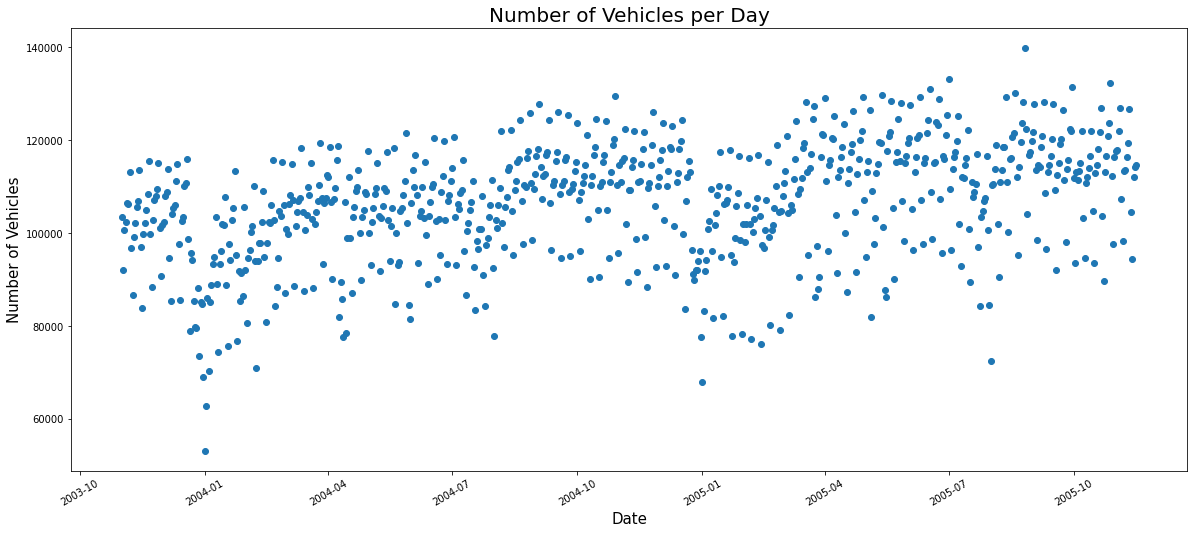

In [4]:
import matplotlib.pyplot as plt

X = tunnel.index
y = tunnel['NumVehicles']
# X = tunnel.loc[:, ['Time']]  # features
# y = tunnel.loc[:, 'NumVehicles']  # target

plt.figure(figsize=(20,8), dpi=72)
plt.scatter(X, y)
plt.xlabel('Date', fontsize=15)
plt.ylabel('Number of Vehicles', fontsize=15)
plt.title('Number of Vehicles per Day', fontsize=20)
plt.xticks(rotation=30, fontsize=10)

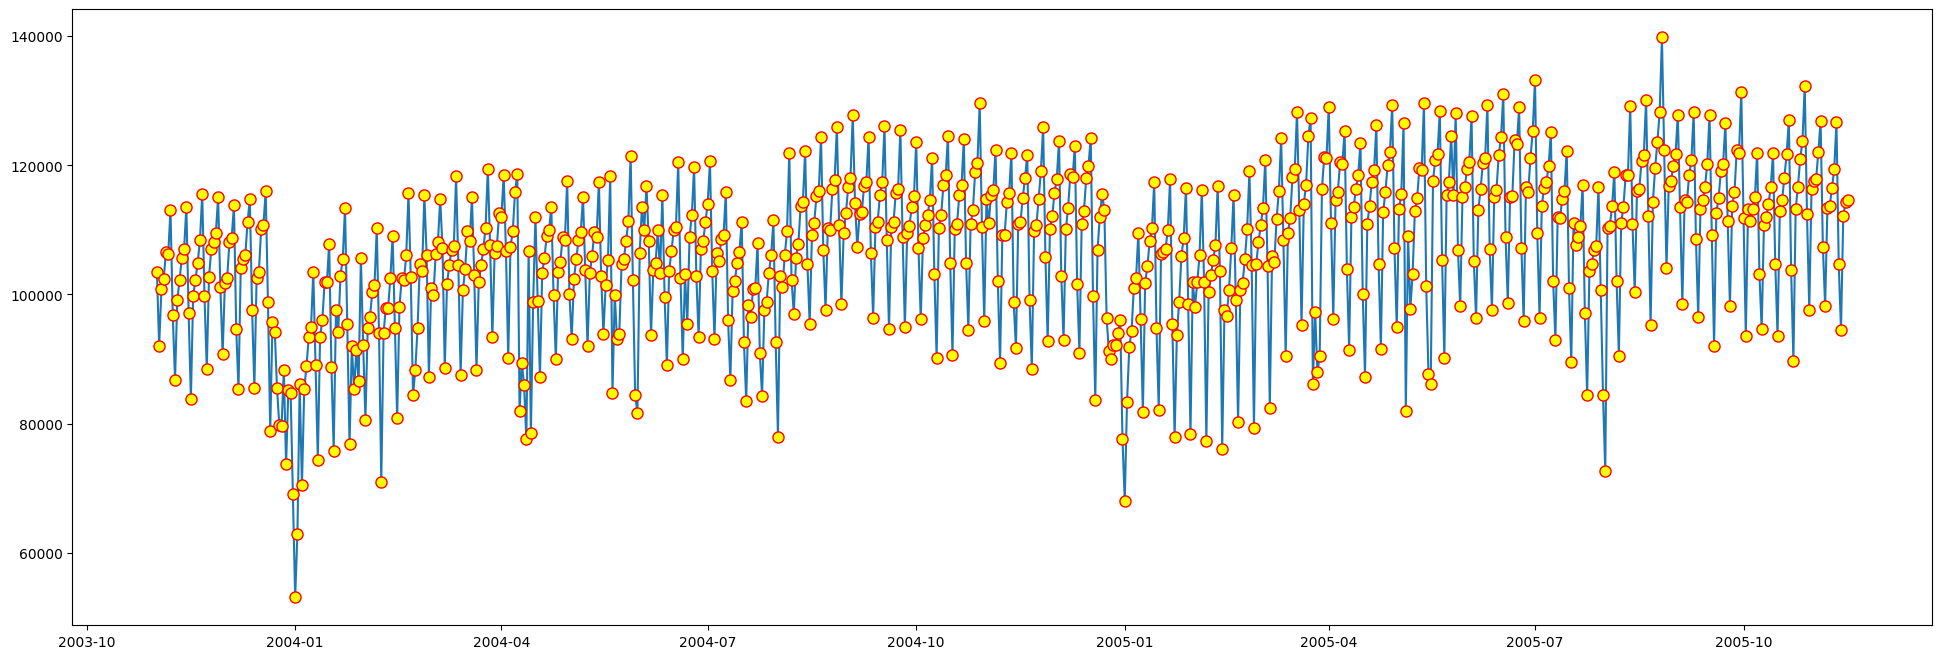

In [5]:
plt.figure(figsize=(24,8))
plt.plot(tunnel.index, tunnel['NumVehicles'], marker='o', markerfacecolor='yellow', markeredgecolor='red', markersize=8)

In [6]:
import numpy as np

tunnel['Time'] = np.arange(len(tunnel.index))
tunnel.head()

,NumVehicles,Time
Day,,
2003-11-01,103536,0
2003-11-02,92051,1
2003-11-03,100795,2
2003-11-04,102352,3
2003-11-05,106569,4


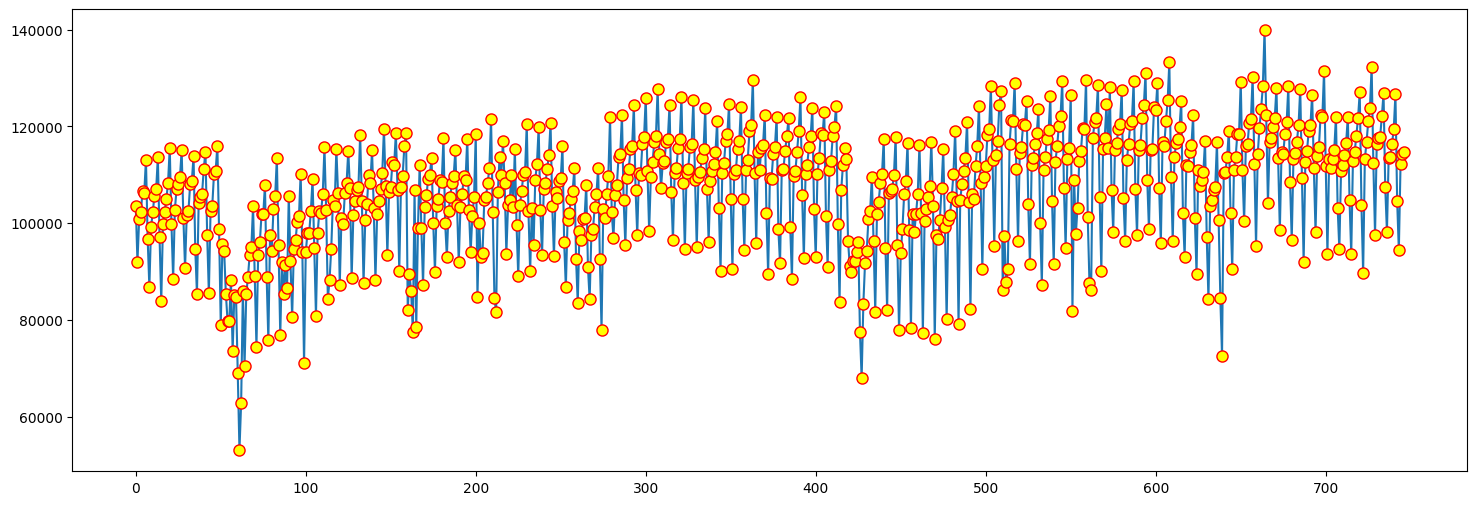

In [7]:
plt.figure(figsize=(18,6))
plt.plot(tunnel['Time'], tunnel['NumVehicles'], marker='o', markerfacecolor='yellow', markeredgecolor='red', markersize=8)

In [8]:
from sklearn.linear_model import LinearRegression

# features, target
X = tunnel.loc[:, ['Time']]  # features
y = tunnel.loc[:, 'NumVehicles']  # target

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as the training data
y_pred = pd.Series(model.predict(X), index=X.index)

Text(0.5, 1.0, 'Time Plot of Tunnel Traffic')

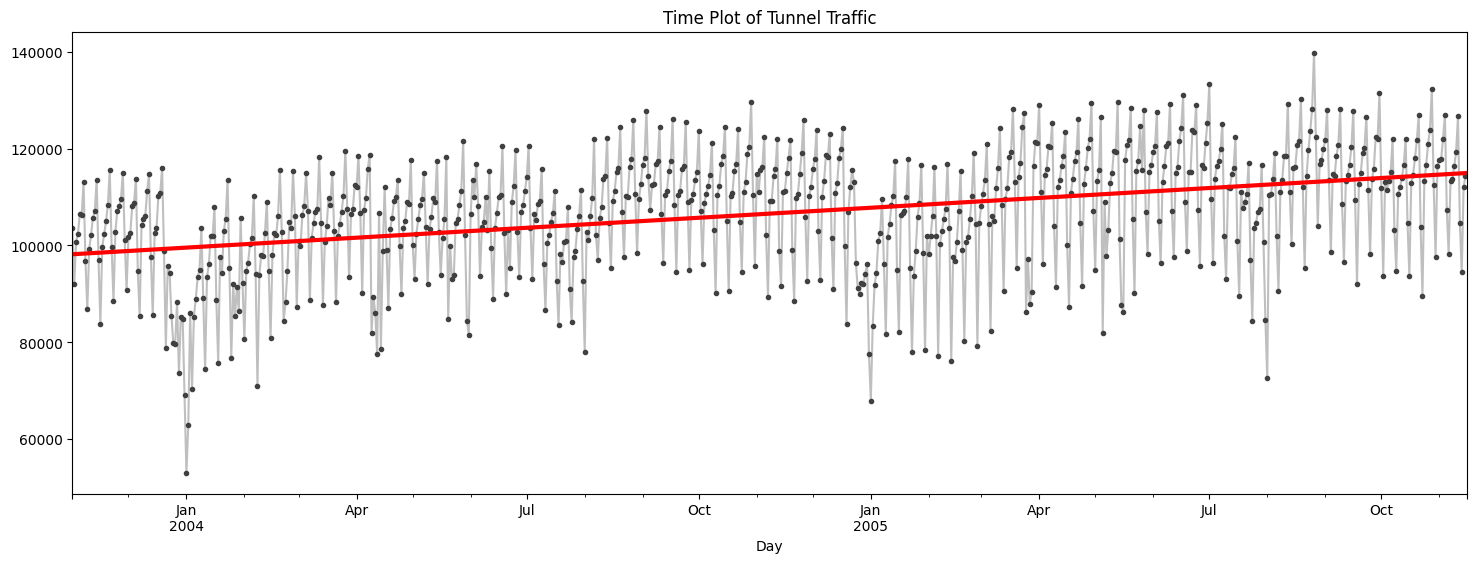

In [9]:
fig, ax = plt.subplots(figsize=(18, 6))

plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)


ax = y.plot(**plot_params)
ax = y_pred.plot(ax=ax, linewidth=3, color="red")
ax.set_title('Time Plot of Tunnel Traffic')


In [10]:
X.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 747 entries, 2003-11-01 to 2005-11-16
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Time    747 non-null    int64
dtypes: int64(1)
memory usage: 11.7 KB


In [11]:
X.head()

,Time
Day,
2003-11-01,0
2003-11-02,1
2003-11-03,2
2003-11-04,3
2003-11-05,4


In [12]:
y.head()

Day
2003-11-01    103536
2003-11-02     92051
2003-11-03    100795
2003-11-04    102352
2003-11-05    106569
Name: NumVehicles, dtype: int64

In [13]:
tunnel['Lag_1'] = tunnel['NumVehicles'].shift(1)
tunnel.head()

,NumVehicles,Time,Lag_1
Day,,,
2003-11-01,103536,0,NaN
2003-11-02,92051,1,103536.0
2003-11-03,100795,2,92051.0
2003-11-04,102352,3,100795.0
2003-11-05,106569,4,102352.0


In [14]:
tunnel.dropna(inplace=True)
tunnel.head()

,NumVehicles,Time,Lag_1
Day,,,
2003-11-02,92051,1,103536.0
2003-11-03,100795,2,92051.0
2003-11-04,102352,3,100795.0
2003-11-05,106569,4,102352.0
2003-11-06,106284,5,106569.0


In [15]:
X = tunnel.loc[:, ['Lag_1']]
y = tunnel.loc[:, 'NumVehicles']

In [16]:
model = LinearRegression()
model.fit(X, y)
y_pred = pd.Series(model.predict(X), index=X.index)

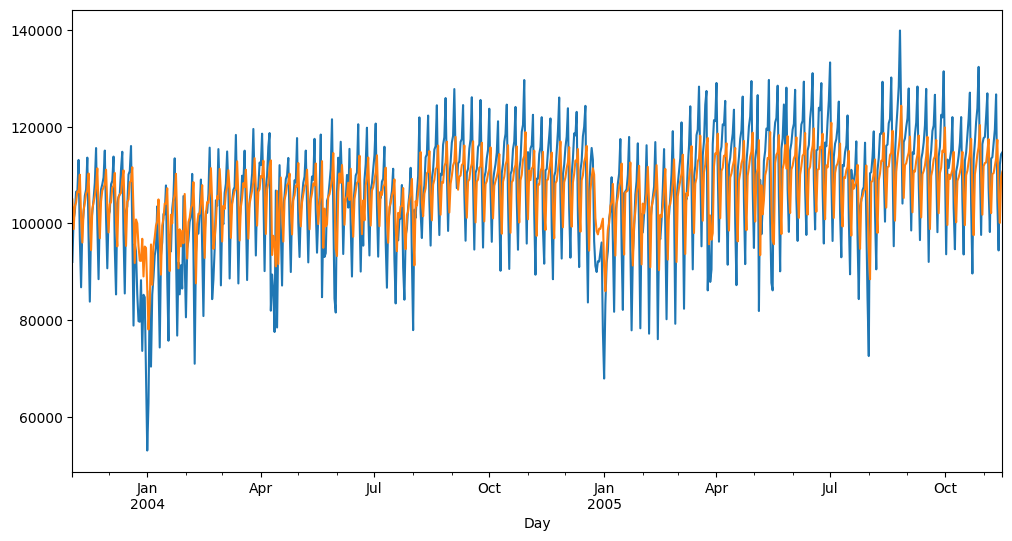

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

ax = y.plot()
ax = y_pred.plot(ax=ax, linewidth=1.5)

In [18]:
# Best-Fit Line
# y=mx+b
# target = weight * feature + bias

# Create a Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X, y)

# Print the intercept and coefficient
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: 49780.624869069565
Coefficient: [0.53296606]
